<a href="https://colab.research.google.com/github/minjilee-purdue/summer2021/blob/main/elpv_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install elpv-dataset -q

In [13]:
from elpv_dataset.utils import load_dataset
import numpy as np

images, proba, types = load_dataset()

print(f"전체 이미지 수: {len(images)}")
print(f"이미지 shape: {images[0].shape}")
print(f"고유 결함 확률 값: {np.unique(proba)}")
print(f"모듈 타입: {np.unique(types)}")

전체 이미지 수: 2624
이미지 shape: (300, 300)
고유 결함 확률 값: [0.         0.33333333 0.66666667 1.        ]
모듈 타입: ['mono' 'poly']


정상 이미지 수: 1508
결함 이미지 수: 715


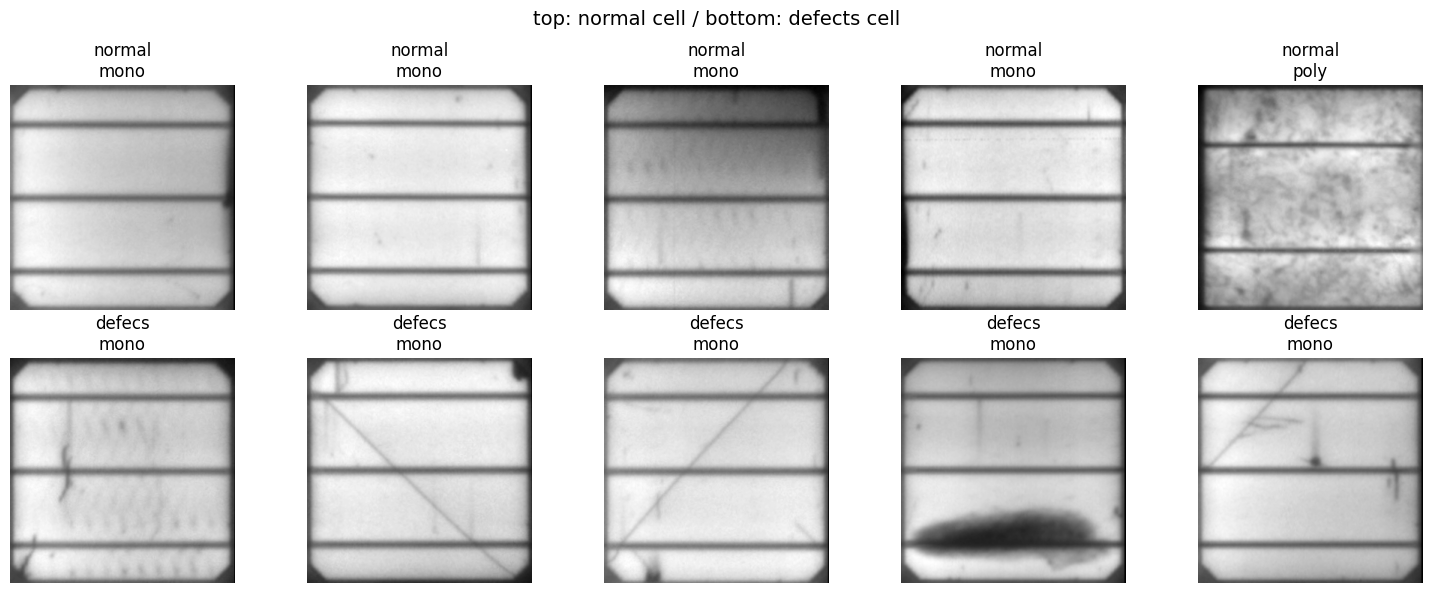

In [14]:
import matplotlib.pyplot as plt

# 완전 정상(0.0)과 확실한 결함(1.0)만 골라내기
normal_idx = np.where(proba == 0.0)[0]
defect_idx = np.where(proba == 1.0)[0]

print(f"정상 이미지 수: {len(normal_idx)}")
print(f"결함 이미지 수: {len(defect_idx)}")

# 각각 5장씩 뽑아서 시각화
n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(15, 6))

for i in range(n_show):
    axes[0, i].imshow(images[normal_idx[i]], cmap='gray')
    axes[0, i].set_title(f"normal\n{types[normal_idx[i]]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(images[defect_idx[i]], cmap='gray')
    axes[1, i].set_title(f"defecs\n{types[defect_idx[i]]}")
    axes[1, i].axis('off')

plt.suptitle("top: normal cell / bottom: defects cell", fontsize=14)
plt.tight_layout()
plt.show()

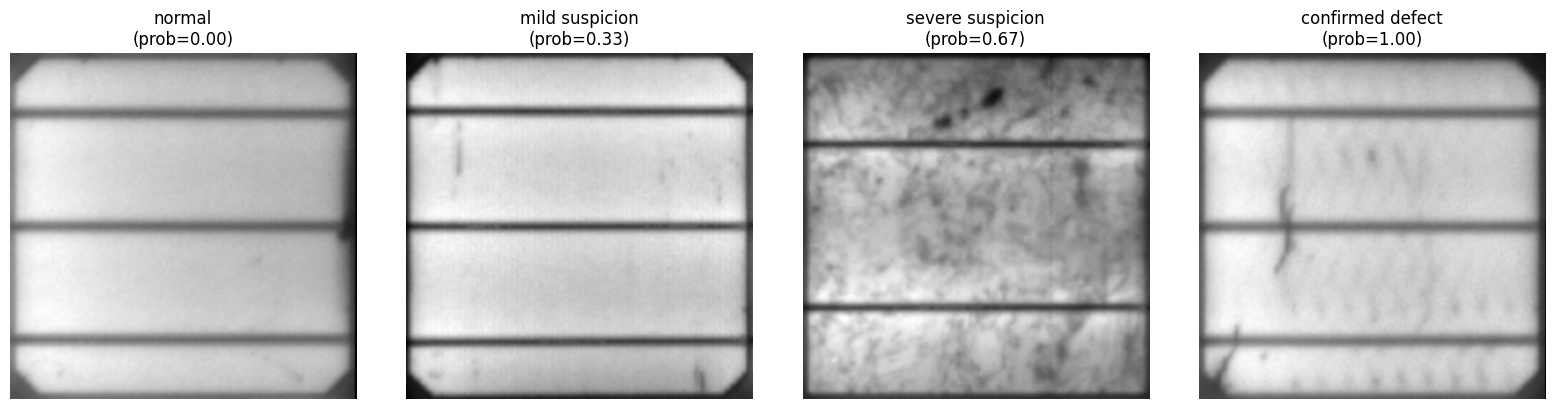

In [15]:
levels = [0.0, 0.3333333333333333, 0.6666666666666666, 1.0]
level_names = ["normal", "mild suspicion", "severe suspicion", "confirmed defect"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, level in enumerate(levels):
    idx = np.where(proba == level)[0][0]  # 각 등급에서 첫 번째 이미지
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(f"{level_names[i]}\n(prob={level:.2f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

왜 supervised인가
각 이미지(images[i])마다 이미 정답 라벨(proba[i])이 붙어있어요 — 이게 핵심이에요.
모델이 "정답을 보면서" 학습하는 구조니까 지도학습(supervised)이고, 반대로 라벨 없이 데이터의 패턴만으로 군집을 찾는 거면 비지도학습(unsupervised), 정상 데이터만 있고 이상치를 찾는 거면 준지도/이상탐지(anomaly detection) 쪽으로 분류돼요.

1. 이상 탐지 (Anomaly Detection) — 가장 널리 쓰임

정상 이미지만 잔뜩 모아서 "정상이 어떻게 생겼는지"만 학습시켜요.
그리고 그 패턴에서 벗어나는 걸 자동으로 "이상하다"고 잡아내요.
장점: 결함 이미지를 굳이 다 라벨링 안 해도 됨 (정상 이미지는 원래 많으니까 모으기 쉬움)
대표 기법: Autoencoder (비지도학습)

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1단계용: 정상(0) vs 의심(0보다 큼)
binary_labels = (proba > 0).astype(int)

# 이미지 정규화 및 채널 차원 추가 (흑백이라 채널 1개)
X = images.astype(np.float32) / 255.0
X = np.expand_dims(X, axis=1)  # (N, 1, 300, 300)

# train/test 분리
X_train, X_test, y_bin_train, y_bin_test, proba_train, proba_test = train_test_split(
    X, binary_labels, proba, test_size=0.2, random_state=42, stratify=binary_labels
)

print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")
print(f"1단계 학습 라벨 분포: {np.bincount(y_bin_train)}")

학습 데이터: (2099, 1, 300, 300), 테스트 데이터: (525, 1, 300, 300)
1단계 학습 라벨 분포: [1206  893]


In [17]:
import torch.nn as nn
import torch.nn.functional as F

class FastBinaryClassifier(nn.Module):
    """1단계: 가볍고 빠른 모델 (레이어 적음)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, stride=2, padding=1)   # 300->150
        self.conv2 = nn.Conv2d(8, 16, 3, stride=2, padding=1)  # 150->75
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(16, 2)  # 정상/의심 2-class

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).flatten(1)
        return self.fc(x)

stage1_model = FastBinaryClassifier()
print(f"1단계 모델 파라미터 수: {sum(p.numel() for p in stage1_model.parameters()):,}")

1단계 모델 파라미터 수: 1,282


In [18]:
class PreciseSeverityClassifier(nn.Module):
    """2단계: 더 깊고 정밀한 모델 (레이어 많음, 1단계에서 걸러진 것만 처리)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, stride=1, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 3)  # 경미(0.333)/심각(0.667)/확실(1.0) 3-class

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

stage2_model = PreciseSeverityClassifier()
print(f"2단계 모델 파라미터 수: {sum(p.numel() for p in stage2_model.parameters()):,}")

2단계 모델 파라미터 수: 62,403


In [19]:
class ELPVDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 1단계용 데이터로더 (정상 vs 의심)
train_ds_stage1 = ELPVDataset(X_train, y_bin_train)
test_ds_stage1 = ELPVDataset(X_test, y_bin_test)

train_loader_stage1 = DataLoader(train_ds_stage1, batch_size=32, shuffle=True)
test_loader_stage1 = DataLoader(test_ds_stage1, batch_size=32, shuffle=False)

print(f"1단계 학습 배치 수: {len(train_loader_stage1)}")

1단계 학습 배치 수: 66


In [20]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
stage1_model = stage1_model.to(device)

optimizer = optim.Adam(stage1_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

n_epochs = 30
for epoch in range(n_epochs):
    stage1_model.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader_stage1:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = stage1_model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader_stage1):.4f} - Acc: {correct/total:.4f}")

Epoch 1/30 - Loss: 0.6785 - Acc: 0.5584
Epoch 2/30 - Loss: 0.6409 - Acc: 0.6527
Epoch 3/30 - Loss: 0.6271 - Acc: 0.6608
Epoch 4/30 - Loss: 0.6236 - Acc: 0.6660
Epoch 5/30 - Loss: 0.6169 - Acc: 0.6732
Epoch 6/30 - Loss: 0.6204 - Acc: 0.6717
Epoch 7/30 - Loss: 0.6182 - Acc: 0.6717
Epoch 8/30 - Loss: 0.6193 - Acc: 0.6732
Epoch 9/30 - Loss: 0.6194 - Acc: 0.6679
Epoch 10/30 - Loss: 0.6159 - Acc: 0.6737
Epoch 11/30 - Loss: 0.6179 - Acc: 0.6732
Epoch 12/30 - Loss: 0.6159 - Acc: 0.6737
Epoch 13/30 - Loss: 0.6143 - Acc: 0.6808
Epoch 14/30 - Loss: 0.6143 - Acc: 0.6832
Epoch 15/30 - Loss: 0.6140 - Acc: 0.6803
Epoch 16/30 - Loss: 0.6155 - Acc: 0.6756
Epoch 17/30 - Loss: 0.6141 - Acc: 0.6779
Epoch 18/30 - Loss: 0.6138 - Acc: 0.6698
Epoch 19/30 - Loss: 0.6162 - Acc: 0.6751
Epoch 20/30 - Loss: 0.6164 - Acc: 0.6760
Epoch 21/30 - Loss: 0.6159 - Acc: 0.6765
Epoch 22/30 - Loss: 0.6142 - Acc: 0.6756
Epoch 23/30 - Loss: 0.6144 - Acc: 0.6737
Epoch 24/30 - Loss: 0.6163 - Acc: 0.6746
Epoch 25/30 - Loss: 0.612

1단계 테스트 정확도: 0.6743
Confidence 분포: 최소 0.501, 최대 0.998, 평균 0.676


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

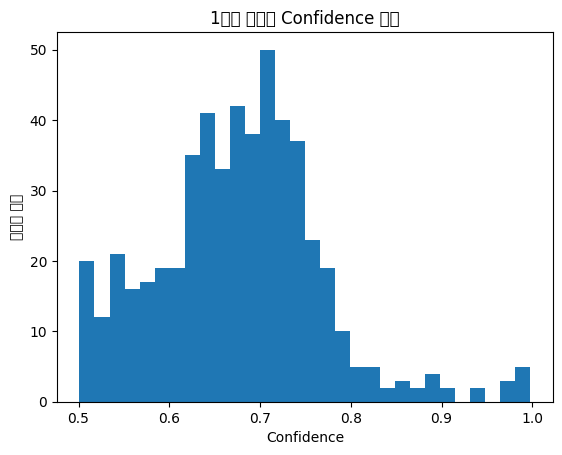

In [21]:
stage1_model.eval()
test_ds_stage1 = ELPVDataset(X_test, y_bin_test)
test_loader_stage1 = DataLoader(test_ds_stage1, batch_size=32, shuffle=False)

all_confidences = []
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader_stage1:
        xb = xb.to(device)
        outputs = stage1_model(xb)
        probs = F.softmax(outputs, dim=1)  # 확률로 변환
        confidence, preds = probs.max(dim=1)  # 가장 높은 확률(confidence)과 그 클래스

        all_confidences.extend(confidence.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

all_confidences = np.array(all_confidences)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"1단계 테스트 정확도: {test_acc:.4f}")
print(f"Confidence 분포: 최소 {all_confidences.min():.3f}, 최대 {all_confidences.max():.3f}, 평균 {all_confidences.mean():.3f}")

import matplotlib.pyplot as plt
plt.hist(all_confidences, bins=30)
plt.xlabel("Confidence")
plt.ylabel("이미지 개수")
plt.title("1단계 모델의 Confidence 분포")
plt.show()

In [22]:
thresholds = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

for th in thresholds:
    escalated = all_confidences < th  # 2단계로 넘어가는 것들
    stage1_only = ~escalated          # 1단계에서 확정하는 것들

    escalation_rate = escalated.mean()
    if stage1_only.sum() > 0:
        stage1_acc = (all_preds[stage1_only] == all_labels[stage1_only]).mean()
    else:
        stage1_acc = float('nan')

    print(f"Threshold {th}: 2단계로 넘어가는 비율 {escalation_rate:.1%}, "
          f"1단계에서 확정한 것들의 정확도 {stage1_acc:.4f}")

Threshold 0.55: 2단계로 넘어가는 비율 9.9%, 1단계에서 확정한 것들의 정확도 0.6913
Threshold 0.6: 2단계로 넘어가는 비율 20.0%, 1단계에서 확정한 것들의 정확도 0.7000
Threshold 0.65: 2단계로 넘어가는 비율 38.1%, 1단계에서 확정한 것들의 정확도 0.7200
Threshold 0.7: 2단계로 넘어가는 비율 59.6%, 1단계에서 확정한 것들의 정확도 0.7925
Threshold 0.75: 2단계로 넘어가는 비율 84.0%, 1단계에서 확정한 것들의 정확도 0.8095
Threshold 0.8: 2단계로 넘어가는 비율 93.7%, 1단계에서 확정한 것들의 정확도 0.8788


In [23]:
class FastBinaryClassifierV2(nn.Module):
    """1단계 v2: 채널 수를 늘리고 conv layer 하나 추가"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)   # 300->150
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)  # 150->75
        self.conv3 = nn.Conv2d(32, 32, 3, stride=2, padding=1)  # 75->38 (추가된 층)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).flatten(1)
        return self.fc(x)

stage1_model_v2 = FastBinaryClassifierV2().to(device)
print(f"1단계 v2 파라미터 수: {sum(p.numel() for p in stage1_model_v2.parameters()):,}")

optimizer = optim.Adam(stage1_model_v2.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

n_epochs = 10
for epoch in range(n_epochs):
    stage1_model_v2.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader_stage1:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = stage1_model_v2(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader_stage1):.4f} - Acc: {correct/total:.4f}")

1단계 v2 파라미터 수: 14,114
Epoch 1/10 - Loss: 0.6657 - Acc: 0.5941
Epoch 2/10 - Loss: 0.6314 - Acc: 0.6570
Epoch 3/10 - Loss: 0.6188 - Acc: 0.6779
Epoch 4/10 - Loss: 0.6192 - Acc: 0.6732
Epoch 5/10 - Loss: 0.6177 - Acc: 0.6765
Epoch 6/10 - Loss: 0.6137 - Acc: 0.6760
Epoch 7/10 - Loss: 0.6133 - Acc: 0.6784
Epoch 8/10 - Loss: 0.6172 - Acc: 0.6741
Epoch 9/10 - Loss: 0.6166 - Acc: 0.6694
Epoch 10/10 - Loss: 0.6142 - Acc: 0.6770


In [24]:
# 클래스 비율 확인
unique, counts = np.unique(y_bin_train, return_counts=True)
print(f"학습 데이터 클래스 분포: {dict(zip(unique, counts))}")
print(f"비율: {counts / counts.sum()}")

# 그냥 다수 클래스로만 찍었을 때 test 정확도
majority_class = unique[np.argmax(counts)]
baseline_acc = (y_bin_test == majority_class).mean()
print(f"\n'무조건 {majority_class}로 찍기' baseline 정확도: {baseline_acc:.4f}")

학습 데이터 클래스 분포: {np.int64(0): np.int64(1206), np.int64(1): np.int64(893)}
비율: [0.57455931 0.42544069]

'무조건 0로 찍기' baseline 정확도: 0.5752


In [25]:
# proba_test는 아까 train_test_split에서 나눈 원래(4단계) 라벨
for level in [0.0, 0.3333333333333333, 0.6666666666666666, 1.0]:
    mask = proba_test == level
    if mask.sum() > 0:
        # stage1_model_v2로 이 그룹만 예측
        acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"결함 정도 {level:.3f} (개수 {mask.sum()}): 정확도 {acc:.4f}")

결함 정도 0.000 (개수 302): 정확도 0.8940
결함 정도 0.333 (개수 62): 정확도 0.0806
결함 정도 0.667 (개수 20): 정확도 0.1500
결함 정도 1.000 (개수 141): 정확도 0.5390


In [26]:
import torch.optim as optim

# 클래스 가중치 계산 (소수 클래스에 더 큰 가중치)
class_counts = torch.tensor([1206, 893], dtype=torch.float32)  # [정상 개수, 의심 개수]
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2  # 정규화 (평균이 1 근처가 되도록)

print(f"클래스 가중치: {class_weights}")
# 정상(0)에 곱해질 가중치는 작고, 의심(1)에 곱해질 가중치는 큼

# 모델 새로 초기화 (v2 구조 그대로, weighted loss만 다르게)
stage1_model_weighted = FastBinaryClassifierV2().to(device)
optimizer = optim.Adam(stage1_model_weighted.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))  # ← 여기가 핵심 변경점

n_epochs = 15
for epoch in range(n_epochs):
    stage1_model_weighted.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader_stage1:
        xb, yb = xb.to(device), yb.to(device)

클래스 가중치: tensor([0.8509, 1.1491])


In [27]:
stage1_model_weighted.eval()
all_preds_w = []
all_labels_w = []

with torch.no_grad():
    for xb, yb in test_loader_stage1:
        xb = xb.to(device)
        outputs = stage1_model_weighted(xb)
        preds = outputs.argmax(dim=1)
        all_preds_w.extend(preds.cpu().numpy())
        all_labels_w.extend(yb.numpy())

all_preds_w = np.array(all_preds_w)
all_labels_w = np.array(all_labels_w)

overall_acc = (all_preds_w == all_labels_w).mean()
print(f"전체 정확도: {overall_acc:.4f}\n")

for level in [0.0, 0.3333333333333333, 0.6666666666666666, 1.0]:
    mask = proba_test == level
    if mask.sum() > 0:
        acc = (all_preds_w[mask] == all_labels_w[mask]).mean()
        print(f"결함 정도 {level:.3f} (개수 {mask.sum()}): 정확도 {acc:.4f}")

전체 정확도: 0.4248

결함 정도 0.000 (개수 302): 정확도 0.0000
결함 정도 0.333 (개수 62): 정확도 1.0000
결함 정도 0.667 (개수 20): 정확도 1.0000
결함 정도 1.000 (개수 141): 정확도 1.0000


In [28]:
# 훨씬 완만한 가중치 (극단으로 안 쏠리게)
class_weights_soft = torch.tensor([1.0, 1.3])  # 정상은 그대로, 의심에만 살짝 가중치

stage1_model_weighted_v2 = FastBinaryClassifierV2().to(device)
optimizer = optim.Adam(stage1_model_weighted_v2.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights_soft.to(device))

n_epochs = 15
for epoch in range(n_epochs):
    stage1_model_weighted_v2.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader_stage1:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = stage1_model_weighted_v2(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader_stage1):.4f} - Acc: {correct/total:.4f}")

Epoch 1/15 - Loss: 0.6853 - Acc: 0.5641
Epoch 2/15 - Loss: 0.6558 - Acc: 0.6189
Epoch 3/15 - Loss: 0.6382 - Acc: 0.6646
Epoch 4/15 - Loss: 0.6293 - Acc: 0.6760
Epoch 5/15 - Loss: 0.6289 - Acc: 0.6746
Epoch 6/15 - Loss: 0.6311 - Acc: 0.6779
Epoch 7/15 - Loss: 0.6325 - Acc: 0.6803
Epoch 8/15 - Loss: 0.6309 - Acc: 0.6789
Epoch 9/15 - Loss: 0.6289 - Acc: 0.6727
Epoch 10/15 - Loss: 0.6292 - Acc: 0.6722
Epoch 11/15 - Loss: 0.6259 - Acc: 0.6841
Epoch 12/15 - Loss: 0.6268 - Acc: 0.6794
Epoch 13/15 - Loss: 0.6269 - Acc: 0.6803
Epoch 14/15 - Loss: 0.6248 - Acc: 0.6822
Epoch 15/15 - Loss: 0.6287 - Acc: 0.6798


In [29]:
stage1_model_weighted_v2.eval()
all_preds_soft = []
all_labels_soft = []

with torch.no_grad():
    for xb, yb in test_loader_stage1:
        xb = xb.to(device)
        outputs = stage1_model_weighted_v2(xb)
        preds = outputs.argmax(dim=1)
        all_preds_soft.extend(preds.cpu().numpy())
        all_labels_soft.extend(yb.numpy())

all_preds_soft = np.array(all_preds_soft)
all_labels_soft = np.array(all_labels_soft)

overall_acc = (all_preds_soft == all_labels_soft).mean()
print(f"전체 정확도: {overall_acc:.4f}\n")

# 결함 정도별 Recall
print("=== 결함 정도별 Recall (진짜 그 등급인 것 중 몇 %를 맞췄나) ===")
for level in [0.0, 0.3333333333333333, 0.6666666666666666, 1.0]:
    mask = proba_test == level
    if mask.sum() > 0:
        acc = (all_preds_soft[mask] == all_labels_soft[mask]).mean()
        print(f"결함 정도 {level:.3f} (개수 {mask.sum()}): Recall {acc:.4f}")

# Precision 계산 (모델이 "의심(1)"이라고 찍은 것들 중 진짜 결함 비율)
predicted_positive = (all_preds_soft == 1)
true_positive = ((all_preds_soft == 1) & (all_labels_soft == 1)).sum()
precision = true_positive / predicted_positive.sum() if predicted_positive.sum() > 0 else 0
print(f"\n=== Precision ===")
print(f"모델이 '의심(1)'이라고 찍은 개수: {predicted_positive.sum()}")
print(f"그 중 진짜 결함: {true_positive}")
print(f"Precision: {precision:.4f}")

# 전체 Recall (결함 전체 기준, 1로 라벨된 것들 중 맞춘 비율)
actual_positive = (all_labels_soft == 1)
recall = true_positive / actual_positive.sum() if actual_positive.sum() > 0 else 0
print(f"\n전체 Recall (결함 전체 기준): {recall:.4f}")

전체 정확도: 0.6590

=== 결함 정도별 Recall (진짜 그 등급인 것 중 몇 %를 맞췄나) ===
결함 정도 0.000 (개수 302): Recall 0.8079
결함 정도 0.333 (개수 62): Recall 0.1613
결함 정도 0.667 (개수 20): Recall 0.2500
결함 정도 1.000 (개수 141): Recall 0.6170

=== Precision ===
모델이 '의심(1)'이라고 찍은 개수: 160
그 중 진짜 결함: 102
Precision: 0.6375

전체 Recall (결함 전체 기준): 0.4574


In [30]:
# train 데이터 중 결함이 있는 것들만 골라서 2단계 학습 데이터로 사용
defect_mask_train = proba_train > 0

X_train_stage2 = X_train[defect_mask_train]
proba_train_stage2 = proba_train[defect_mask_train]

# 심각도 3-class 라벨로 변환: 0.333->0(경미), 0.667->1(심각), 1.0->2(확실)
severity_map = {0.3333333333333333: 0, 0.6666666666666666: 1, 1.0: 2}
y_severity_train = np.array([severity_map[p] for p in proba_train_stage2])

print(f"2단계 학습 데이터 개수: {len(X_train_stage2)}")
print(f"심각도별 분포: {np.bincount(y_severity_train)}")

train_ds_stage2 = ELPVDataset(X_train_stage2, y_severity_train)
train_loader_stage2 = DataLoader(train_ds_stage2, batch_size=16, shuffle=True)

2단계 학습 데이터 개수: 893
심각도별 분포: [233  86 574]


In [31]:
# 2단계 모델 (아까 정의했던 PreciseSeverityClassifier 재사용)
stage2_model = PreciseSeverityClassifier().to(device)

# 클래스 가중치 계산 (적은 클래스에 더 큰 가중치, 완만하게)
severity_counts = torch.tensor([233, 86, 574], dtype=torch.float32)
severity_weights = 1.0 / severity_counts
severity_weights = severity_weights / severity_weights.sum() * 3  # 정규화

print(f"심각도 클래스 가중치: {severity_weights}")

optimizer_s2 = optim.Adam(stage2_model.parameters(), lr=1e-3)
criterion_s2 = nn.CrossEntropyLoss(weight=severity_weights.to(device))

n_epochs = 10
for epoch in range(n_epochs):
    stage2_model.train()
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in train_loader_stage2:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_s2.zero_grad()
        outputs = stage2_model(xb)
        loss = criterion_s2(outputs, yb)
        loss.backward()
        optimizer_s2.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader_stage2):.4f} - Acc: {correct/total:.4f}")

심각도 클래스 가중치: tensor([0.7290, 1.9751, 0.2959])
Epoch 1/10 - Loss: 1.0987 - Acc: 0.6428
Epoch 2/10 - Loss: 1.0612 - Acc: 0.5969
Epoch 3/10 - Loss: 1.0283 - Acc: 0.5857
Epoch 4/10 - Loss: 1.0181 - Acc: 0.5789
Epoch 5/10 - Loss: 1.0175 - Acc: 0.6103
Epoch 6/10 - Loss: 1.0150 - Acc: 0.5789
Epoch 7/10 - Loss: 1.0116 - Acc: 0.5924
Epoch 8/10 - Loss: 1.0090 - Acc: 0.6103
Epoch 9/10 - Loss: 1.0109 - Acc: 0.6025
Epoch 10/10 - Loss: 1.0124 - Acc: 0.5980


In [32]:
stage2_model.eval()
all_preds_s2 = []
all_labels_s2 = []

# 2단계 테스트 데이터도 준비 필요 (결함 있는 test 샘플만)
defect_mask_test = proba_test > 0
X_test_stage2 = X_test[defect_mask_test]
proba_test_stage2 = proba_test[defect_mask_test]
y_severity_test = np.array([severity_map[p] for p in proba_test_stage2])

test_ds_stage2 = ELPVDataset(X_test_stage2, y_severity_test)
test_loader_stage2 = DataLoader(test_ds_stage2, batch_size=16, shuffle=False)

with torch.no_grad():
    for xb, yb in test_loader_stage2:
        xb = xb.to(device)
        outputs = stage2_model(xb)
        preds = outputs.argmax(dim=1)
        all_preds_s2.extend(preds.cpu().numpy())
        all_labels_s2.extend(yb.numpy())

all_preds_s2 = np.array(all_preds_s2)
all_labels_s2 = np.array(all_labels_s2)

overall_acc_s2 = (all_preds_s2 == all_labels_s2).mean()
print(f"2단계 전체 정확도: {overall_acc_s2:.4f}\n")

severity_names = ["경미(0.333)", "심각(0.667)", "확실(1.0)"]
for cls in [0, 1, 2]:
    mask = y_severity_test == cls
    if mask.sum() > 0:
        recall = (all_preds_s2[mask] == cls).mean()
        print(f"{severity_names[cls]} (개수 {mask.sum()}): Recall {recall:.4f}")

2단계 전체 정확도: 0.5740

경미(0.333) (개수 62): Recall 0.9194
심각(0.667) (개수 20): Recall 0.0000
확실(1.0) (개수 141): Recall 0.5035
